# Overview

## Description

This is a template notebook to tune up a single qubit using the LabOneQ workflow architecture. The following tune-up experiments are implemented:

1. Resonator Spectroscopy
2. Qubit Spectroscopy
3. Amplitude Rabi Experiment
4. Ramsey Experiment
5. T1 Lifetime experiment
6. DRAG Calibration
7. Hahn-Echo Experiment

All experiments can be performed on the ge and ef transition.

## Changelog

All changes must be logged here! Do not make changes to this notebook other than expanding or modifying the standard experiments in a meaningful! All device-specific parameters and measurements have to be done in a different notebook!

Stick to semantic versioning:
- **Last Digit**: Fix a bug that does not add any new features and is backwards compatible -> increment last digit by one (e.g. 0.0.4 to 0.0.5)

- **Middle Digit**: Add a new feature while keeping backwards compatibility (older versions can still be executed without any modifications) -> increment middle digit by one and set last digit to 0 (e.g. 1.2.12 to 1.3.0)

- **First Digit**: Make changes that will break older versions, making them incompatible with the new version -> increment first digit by one and set all other digits to 0 (e.g. 3.2.9 to 4.0.0)

**Current Version:** 1.0.0

**2026-07-23**, *Elias*: Created this template notebook and added resonator and qubit spectroscopy, amplitude Rabi, Ramsey T1 and DRAG

# Package Imports and Initialization

## LabOne Q Libraries

In [1]:
# LabOne Q:
from laboneq.simple import *
from laboneq.dsl.quantum import QPU
from laboneq.contrib.example_helpers.generate_descriptor import generate_descriptor
from laboneq.workflow.logbook import LoggingStore
from laboneq.serializers import load, save

# LabOne Q Applications:
from laboneq_applications.qpu_types.tunable_transmon import (
    TunableTransmonQubit,
    TunableTransmonOperations,
)

# Plot:
from laboneq.contrib.example_helpers.plotting.plot_helpers import plot_results, plot_simulation

# Workflows:
from laboneq_applications.experiments import (
    resonator_spectroscopy,
    resonator_spectroscopy_amplitude,
    qubit_spectroscopy,
    amplitude_rabi,
    ramsey,
    drag_q_scaling,
    lifetime_measurement,
    echo,
)

## Other Imports

In [2]:
from copy import deepcopy
from pprint import pprint
import numpy as np
import time
from pathlib import Path
import os

In [3]:
def set_transition(transition: str):
    assert transition in ['ge', 'ef'], "Choose transition from 'ge' or 'ef'!"
    return transition

def log_sweep_help(t1_min: float, t1_max: float, t1_num: int):
    t1_log_sweep = np.logspace(np.log10(t1_max / t1_num / 10), np.log10(t1_max), t1_num - 1)
    t1_log_sweep_arr = np.append([0.0], t1_log_sweep)
    return t1_log_sweep_arr

## Descriptor and Device Setup

In [4]:
number_of_qubits = 1

descriptor = generate_descriptor(
    #pqsc=["DEV10001"],
    shfqc_2=["DEV12192"],
    number_data_qubits=number_of_qubits,
    multiplex=True,
    number_multiplex=number_of_qubits,
    include_cr_lines=False,
    ip_address="localhost",
    #options = "SHFQC/QC2CH",
)

setup = DeviceSetup.from_descriptor(descriptor, "localhost")
setup.instruments[0].device_options = "SHFQC/QC2CH"

In [5]:
qubits = TunableTransmonQubit.from_device_setup(setup)

## Qubit Initialization

In [6]:
cooldown_start_date = '2026-08-04' # YYYY-MM-DD
sample_name = 'ES-008-BC_2-1_8853_CD2'
qubit_name = 'Q1'

assert cooldown_start_date != '', 'Enter cooldown name'
assert sample_name != '', 'Enter sample name'
assert qubit_name != '', 'Enter qubit name'

In [7]:
for q in qubits:
    q.parameters.ge_drive_pulse["sigma"] = 0.25
    q.parameters.readout_amplitude = 0.5
    q.parameters.reset_delay_length = 150e-6
    q.parameters.readout_range_out = -25 
    q.parameters.readout_lo_frequency = 5e9 # ok
    q.parameters.drive_range = 5
    q.parameters.readout_range_in = -45
    q.parameters.readout_integration_delay = 80e-9

qubits[0].parameters.drive_lo_frequency = 3.6e9 # ok
qubits[0].parameters.resonance_frequency_ge = 3.748e9
qubits[0].parameters.resonance_frequency_ef = 3.508e9
qubits[0].parameters.readout_resonator_frequency = 5.032e9
qubits[0].parameters.spectroscopy_length = 5e-6
qubits[0].parameters.spectroscopy_amplitude = 0.5
qubits[0].uid = qubit_name

In [8]:
qops = TunableTransmonOperations()
qpu = QPU(qubits, quantum_operations=qops)

In [9]:
for q in qubits:
    print("-------------")
    print("Qubit UID:", q.uid)
    print("Qubit logical signals:")
    for sig, lsg in q.signals.items():
        print(f"  {sig:<10} ('{lsg:>10}')")

-------------
Qubit UID: Q1
Qubit logical signals:
  drive      ('  q0/drive')
  drive_ef   ('q0/drive_ef')
  measure    ('q0/measure')
  acquire    ('q0/acquire')


## LabOne Q Session Connection

In [10]:
session = Session(setup)
session.connect(do_emulation=False)

[2026.08.04 18:47:21.632] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is C:\Users\phys-pico-lab\Documents\Python_virtual_environments\meas_venv_workflow_py312\Scripts\meas\laboneq_output\log
[2026.08.04 18:47:21.648] INFO    VERSION: laboneq 26.4.0
[2026.08.04 18:47:21.655] INFO    Connecting to data server at localhost:8004
[2026.08.04 18:47:21.664] INFO    Connected to Zurich Instruments LabOne Data Server version 26.04.1.6 at localhost:8004
[2026.08.04 18:47:21.680] INFO    Configuring the device setup
[2026.08.04 18:47:21.691] INFO    The device setup is configured
[2026.08.04 18:47:21.939] INFO    System profile saved to C:\Users\phys-pico-lab\AppData\Local\laboneq\profiles\unknown-613335402d7b7f78058d100a7c9ddd62592a6fd7431fa79c3e5a4ab0cfd13ec3.yaml


## Data Saving

In [11]:
data_root_directory = os.path.join('N:\\', 'xld', 'qubit_thermometry_v2', sample_name, f'COOLDOWN_{cooldown_start_date}', qubit_name)
qpu_file_path = os.path.join('N:\\', 'xld', 'qubit_thermometry_v2', sample_name, f'COOLDOWN_{cooldown_start_date}', f'{sample_name}_qpu.json')

if not os.path.isdir(data_root_directory):
    os.makedirs(data_root_directory, exist_ok=True)

print(f'Saving data to: {data_root_directory}')

Saving data to: N:\xld\qubit_thermometry_v2\ES-008-BC_2-1_8853_CD2\COOLDOWN_2026-08-04\Q1


In [12]:
folder_store = workflow.logbook.FolderStore(data_root_directory)
folder_store.activate()

logging_store = LoggingStore()
logging_store.activate()

# Tune-Up Experiments

## Spectroscopy

### Resonator Spectroscopy

#### Experiment Parameters

In [13]:
update_global_parameters = True

readout_range_out = -25
readout_range_in = -45
readout_amplitude = 0.2
n_avg_exponent = 15

freq_range = 10e6
n_points = 101

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temp_pars.readout_range_out = readout_range_out
temp_pars.readout_range_in = readout_range_in
temp_pars.readout_amplitude = readout_amplitude
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.08.04 18:47:53.028] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.04 18:47:53.028] INFO      Workflow 'resonator_spectroscopy': execution started at 2026-08-04            
[2026.08.04 18:47:53.028] INFO      15:47:53.026162Z                                                              
[2026.08.04 18:47:53.028] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.04 18:47:53.295] INFO    Task 'temporary_qpu': started at 2026-08-04 15:47:53.293249Z
[2026.08.04 18:47:53.340] INFO    Task 'temporary_qpu': ended at 2026-08-04 15:47:53.340490Z
[2026.08.04 18:47:53.438] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-08-04 
[2026.08.04 18:47:53.438] INFO    15:47:53.438606Z
[2026.08.04 18:47:53.480] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-08-04 15:47:53.480386Z
[2026.08.04 18:47:53.572] INFO    Task 'create_experiment': started at 2026-08-04 15:

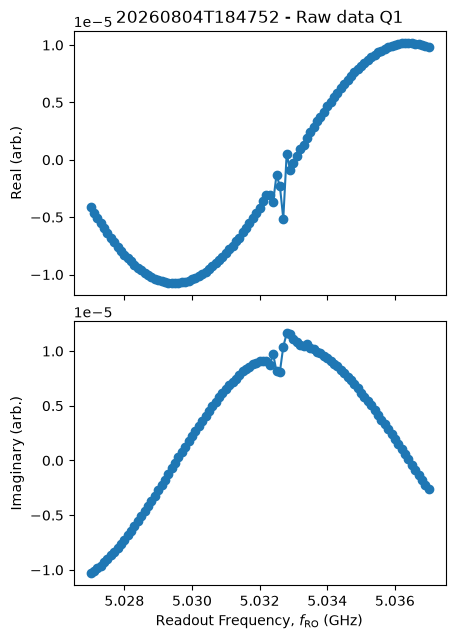

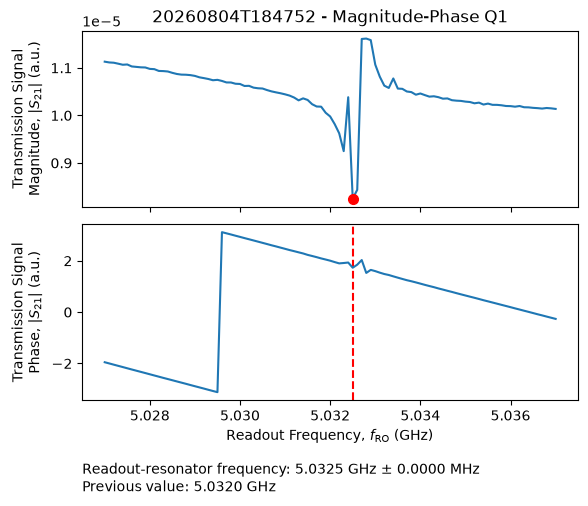

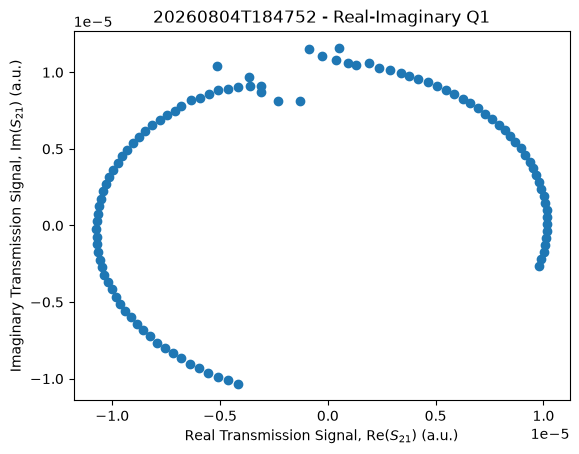

In [14]:
options = resonator_spectroscopy.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(False)

qubit_to_measure = qubits[0]

frequencies = qubits[0].parameters.readout_resonator_frequency + np.linspace(
    -freq_range / 2, freq_range / 2, n_points
)

exp_workflow = resonator_spectroscopy.experiment_workflow(
    session=session,
    qpu=qpu,
    qubit=qubit_to_measure.uid,
    frequencies=frequencies,
    options=options,
    temporary_parameters=temporary_parameters
)
workflow_result = exp_workflow.run()

#### Update Parameters

In [15]:
if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    save(qpu, qpu_file_path)
    print('Updated global experiment parameters!\n')

analysis_workflow_result= workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)
resonator_spectroscopy.update_qpu(qpu, qubit_parameters["new_parameter_values"])
print("\nReadout resonator frequency: ", qubit_to_measure.parameters.readout_resonator_frequency * 1e-9, ' GHz')

Updated global experiment parameters!

{'new_parameter_values': {'Q1': {'readout_resonator_frequency': 5032500000.0+/-0}},
 'old_parameter_values': {'Q1': {'readout_resonator_frequency': 5032000000.0}}}

Readout resonator frequency:  5.032500000000001  GHz


In [16]:
qubits[0]

TunableTransmonQubit(
│   uid='Q1',
│   signals={
│   │   'drive': 'q0/drive',
│   │   'drive_ef': 'q0/drive_ef',
│   │   'measure': 'q0/measure',
│   │   'acquire': 'q0/acquire'
│   },
│   parameters=TunableTransmonQubitParameters(
│   │   custom={},
│   │   ge_T1=0,
│   │   ge_T2=0,
│   │   ge_T2_star=0,
│   │   ef_T1=0,
│   │   ef_T2=0,
│   │   ef_T2_star=0,
│   │   drive_lo_frequency=3600000000.0,
│   │   readout_lo_frequency=5000000000.0,
│   │   resonance_frequency_ge=3748000000.0,
│   │   resonance_frequency_ef=3508000000.0,
│   │   readout_resonator_frequency=5032500000.0,
│   │   ge_drive_amplitude_pi=0.2,
│   │   ge_drive_amplitude_pi2=0.1,
│   │   ge_drive_length=5e-08,
│   │   ge_drive_pulse={
│   │   │   'function': 'drag',
│   │   │   'beta': 0,
│   │   │   'sigma': 0.25
│   │   },
│   │   ef_drive_amplitude_pi=0.2,
│   │   ef_drive_amplitude_pi2=0.1,
│   │   ef_drive_length=5e-08,
│   │   ef_drive_pulse={
│   │   │   'function': 'drag',
│   │   │   'beta': 0,
│   │   │  

## Qubit Spectroscopy

#### Experiment Parameters

In [17]:
update_global_parameters = True

spectroscopy_length = 2e-6
spectroscopy_amplitude = 1
readout_amplitude = 0.1
drive_range = -30
n_avg_exponent = 13

freq_range = 100e6
n_points = 251

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temp_pars.spectroscopy_length = spectroscopy_length
temp_pars.spectroscopy_amplitude = spectroscopy_amplitude
temp_pars.readout_amplitude = readout_amplitude
temp_pars.drive_range = drive_range
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.08.04 18:50:38.638] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.04 18:50:38.638] INFO      Workflow 'qubit_spectroscopy': execution started at 2026-08-04                
[2026.08.04 18:50:38.638] INFO      15:50:38.638684Z                                                              
[2026.08.04 18:50:38.638] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.04 18:50:38.904] INFO    Task 'temporary_qpu': started at 2026-08-04 15:50:38.904019Z
[2026.08.04 18:50:38.948] INFO    Task 'temporary_qpu': ended at 2026-08-04 15:50:38.944868Z
[2026.08.04 18:50:39.029] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-08-04 
[2026.08.04 18:50:39.029] INFO    15:50:39.029267Z
[2026.08.04 18:50:39.070] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-08-04 15:50:39.070061Z
[2026.08.04 18:50:39.164] INFO    Task 'create_experiment': started at 2026-08-04 15:

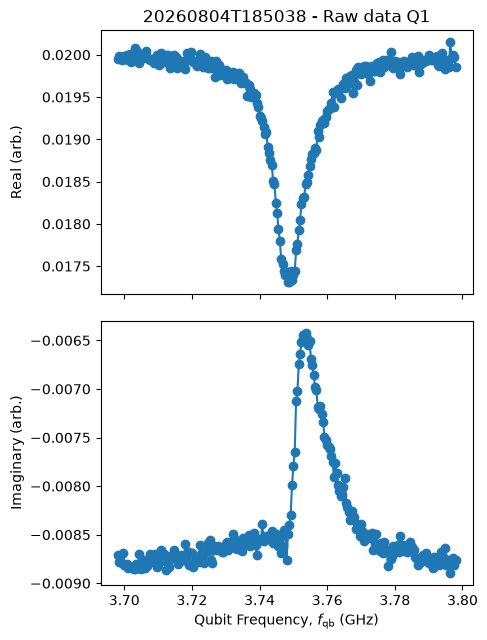

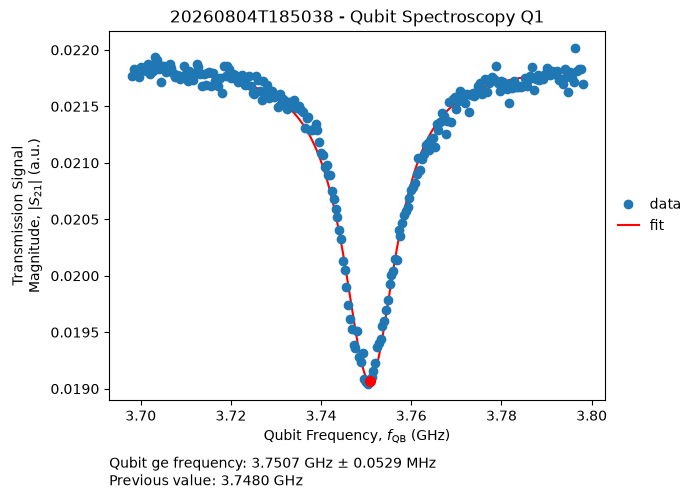

In [18]:
options = qubit_spectroscopy.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.update(False) 
options.close_figures(False)

qubits_to_measure = [qubits[0]]

frequencies = [
    temporary_parameters[q.uid].resonance_frequency_ge + np.linspace(- freq_range / 2, freq_range / 2, n_points)
    for q in qubits_to_measure
]
exp_workflow = qubit_spectroscopy.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    frequencies=frequencies,
    options=options,
    temporary_parameters=temporary_parameters
)
workflow_result = exp_workflow.run()

#### Update Parameters

In [19]:
manual_center_frequency = 3.75e9
temporary_parameters[qubit_to_measure.uid].resonance_frequency_ge = manual_center_frequency

In [20]:
if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    save(qpu, qpu_file_path)
    print('Updated global experiment parameters!\n')

analysis_workflow_result= workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)
qubit_spectroscopy.update_qpu(qpu, qubit_parameters["new_parameter_values"])
print("Readout resonance frequency ge: ", qubit_to_measure.parameters.resonance_frequency_ge)

Updated global experiment parameters!

{'new_parameter_values': {'Q1': {'resonance_frequency_ge': 3750741371.056663+/-52894.24918113357}},
 'old_parameter_values': {'Q1': {'resonance_frequency_ge': 3748000000.0}}}
Readout resonance frequency ge:  3750741371.056663


# Control Pulses

## Amplitude Rabi

#### Experiment Parameters

In [21]:
update_global_parameters = True

transition = set_transition('ge')

drive_range = -5
drive_length = 50e-9
readout_amplitude = 0.5
n_avg_exponent = 13

amp_min = 0
amp_max = 1
n_amp = 21

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temp_pars.drive_range = drive_range
temp_pars.readout_amplitude = readout_amplitude
if transition == 'ge':
    temp_pars.ge_drive_length = drive_length
elif transition == 'ef':
    temp_pars.ef_drive_length = drive_length
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.08.04 18:51:27.826] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.04 18:51:27.826] INFO      Workflow 'amplitude_rabi': execution started at 2026-08-04 15:51:27.826409Z   
[2026.08.04 18:51:27.826] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.04 18:51:27.997] INFO    Task 'temporary_qpu': started at 2026-08-04 15:51:27.995432Z
[2026.08.04 18:51:28.022] INFO    Task 'temporary_qpu': ended at 2026-08-04 15:51:28.022775Z
[2026.08.04 18:51:28.079] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-08-04 
[2026.08.04 18:51:28.081] INFO    15:51:28.078321Z
[2026.08.04 18:51:28.109] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-08-04 15:51:28.108395Z
[2026.08.04 18:51:28.170] INFO    Task 'create_experiment': started at 2026-08-04 15:51:28.170071Z
[2026.08.04 18:51:28.239] INFO    Task 'create_experiment': ended at 2026-08-04 15:51:28.239260Z
[202

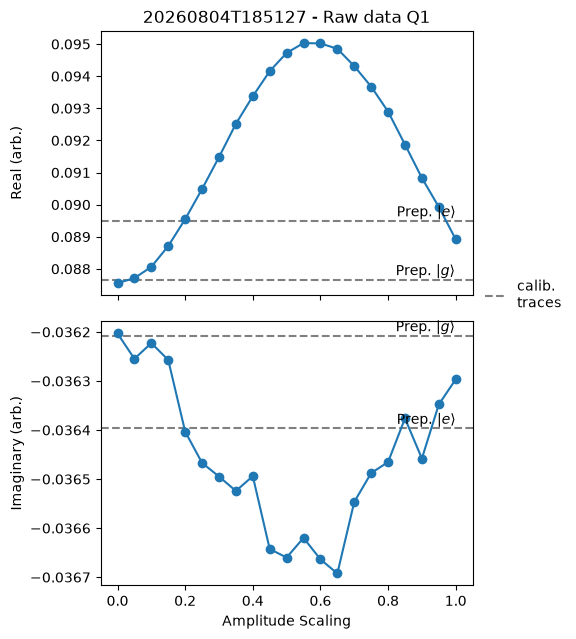

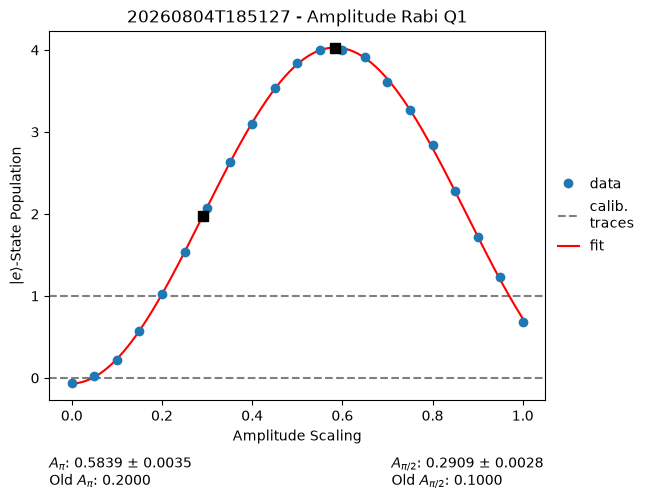

In [22]:
options = amplitude_rabi.experiment_workflow.options()

options.count(2**n_avg_exponent)
options.close_figures(False) # Plot figures

options.transition(transition)
options.cal_states(transition)

qubits_to_measure = [qubits[0]]

exp_workflow = amplitude_rabi.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    amplitudes=[np.linspace(amp_min, amp_max, n_amp) for q in qubits_to_measure],
    options=options,
    temporary_parameters=temporary_parameters
)
workflow_result = exp_workflow.run()

#### Update Parameters

In [23]:
if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    save(qpu, qpu_file_path)
    print('Updated global experiment parameters!\n')

analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)
amplitude_rabi.update_qpu(qpu, qubit_parameters["new_parameter_values"])
if transition == 'ge':
    print("Drive amplitude pi ge: ", qubit_to_measure.parameters.ge_drive_amplitude_pi)
    print("Drive amplitude pi2 ge: ", qubit_to_measure.parameters.ge_drive_amplitude_pi2)
elif transition == 'ef':
    print("Drive amplitude pi ef: ", qubit_to_measure.parameters.ef_drive_amplitude_pi)
    print("Drive amplitude pi2 ef: ", qubit_to_measure.parameters.ef_drive_amplitude_pi2)

Updated global experiment parameters!

{'new_parameter_values': {'Q1': {'ge_drive_amplitude_pi': 0.5838955473034612+/-0.003547327616104929,
                                 'ge_drive_amplitude_pi2': 0.2908598298472547+/-0.0028316955423455894}},
 'old_parameter_values': {'Q1': {'ge_drive_amplitude_pi': 0.2,
                                 'ge_drive_amplitude_pi2': 0.1}}}
Drive amplitude pi ge:  0.5838955473034612
Drive amplitude pi2 ge:  0.2908598298472547


## Ramsey

#### Experiment Parameters

In [27]:
update_global_parameters = True

detuning = 0.5e6
transition = set_transition('ge')

n_avg_exponent = 13

delay_min = 0
delay_max = 25e-6
n_delay = 201

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.08.04 18:54:53.654] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.04 18:54:53.654] INFO      Workflow 'ramsey': execution started at 2026-08-04 15:54:53.654412Z           
[2026.08.04 18:54:53.654] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.04 18:54:53.896] INFO    Task 'temporary_qpu': started at 2026-08-04 15:54:53.896745Z
[2026.08.04 18:54:53.912] INFO    Task 'temporary_qpu': ended at 2026-08-04 15:54:53.912694Z
[2026.08.04 18:54:53.988] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-08-04 
[2026.08.04 18:54:53.989] INFO    15:54:53.976185Z
[2026.08.04 18:54:54.008] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-08-04 15:54:54.008976Z
[2026.08.04 18:54:54.072] INFO    Task 'create_experiment': started at 2026-08-04 15:54:54.072458Z
[2026.08.04 18:54:54.149] INFO    Task 'create_experiment': ended at 2026-08-04 15:54:54.149853Z
[202

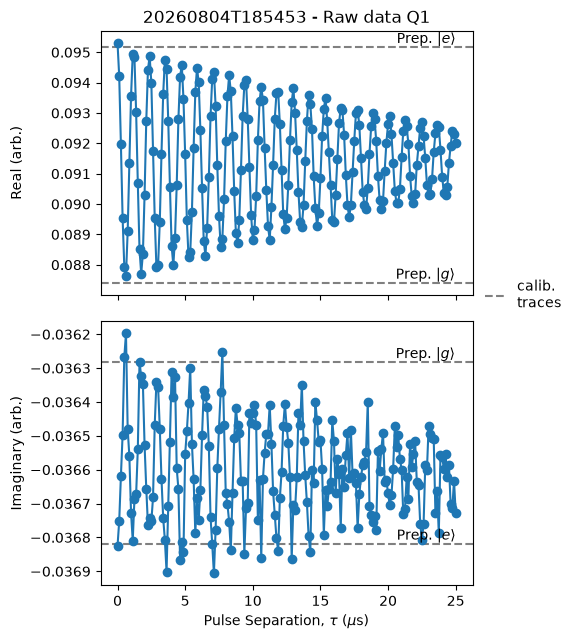

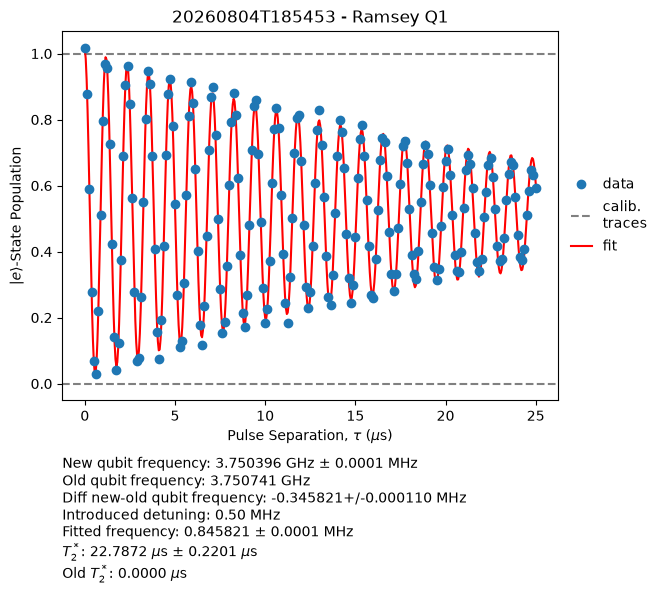

In [28]:
options = ramsey.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(False) # Plot figures

options.transition(transition)
options.cal_states(transition)

# Note: if neighbouring qubits are physically coupled by a resonator,
# you usually don't want to run Ramsey in parallel on them because
# your result will be skewed by strong residual-ZZ coupling.
# Next-nearest neighbours is typically okay.
# qubits_to_measure = [qubits[0], qubits[2]]
qubits_to_measure = [qubits[0]]

delays = [
    np.linspace(delay_min, delay_max, n_delay)
]
detunings = [
    detuning
]

exp_workflow = ramsey.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    delays=delays,
    detunings=detunings,
    options=options,
    temporary_parameters=temporary_parameters
)

workflow_result = exp_workflow.run()

#### Update Parameters

In [29]:
if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    save(qpu, qpu_file_path)
    print('Updated global experiment parameters!\n')

analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)
ramsey.update_qpu(qpu, qubit_parameters["new_parameter_values"])
if transition == 'ge':
    print("ge_T2_star: ", qubit_to_measure.parameters.ge_T2_star)
    print("resonance_frequency_ge: ", qubit_to_measure.parameters.resonance_frequency_ge)
elif transition == 'ef':
    print("ef_T2_star: ", qubit_to_measure.parameters.ef_T2_star)
    print("resonance_frequency_ef: ", qubit_to_measure.parameters.resonance_frequency_ef)

Updated global experiment parameters!

{'new_parameter_values': {'Q1': {'ge_T2_star': 2.278716234815903e-05+/-2.2014339235336053e-07,
                                 'resonance_frequency_ge': 3750395549.644312+/-109.86515948741913}},
 'old_parameter_values': {'Q1': {'ge_T2_star': 0,
                                 'resonance_frequency_ge': 3750741371.056663}}}
ge_T2_star:  2.278716234815903e-05
resonance_frequency_ge:  3750395549.644312


## T1 Lifetime

#### Experiment Parameters

In [24]:
update_global_parameters = True

transition = set_transition('ge')

n_avg_exponent = 13

delay_min = 0
delay_max = 100e-6
n_delay = 51
log_spacing = True

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.08.04 18:52:54.270] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.04 18:52:54.272] INFO      Workflow 'lifetime_measurement': execution started at 2026-08-04              
[2026.08.04 18:52:54.272] INFO      15:52:54.270856Z                                                              
[2026.08.04 18:52:54.274] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.04 18:52:54.503] INFO    Task 'temporary_qpu': started at 2026-08-04 15:52:54.503336Z
[2026.08.04 18:52:54.549] INFO    Task 'temporary_qpu': ended at 2026-08-04 15:52:54.549523Z
[2026.08.04 18:52:54.627] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-08-04 
[2026.08.04 18:52:54.627] INFO    15:52:54.627909Z
[2026.08.04 18:52:54.677] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-08-04 15:52:54.677816Z
[2026.08.04 18:52:54.773] INFO    Task 'create_experiment': started at 2026-08-04 15:

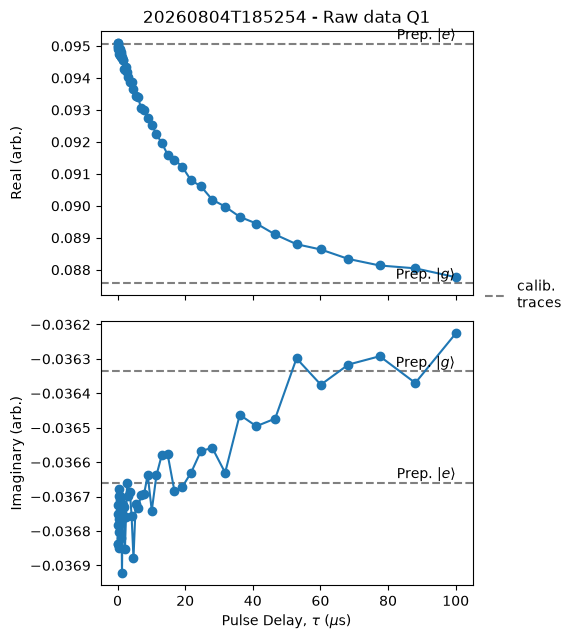

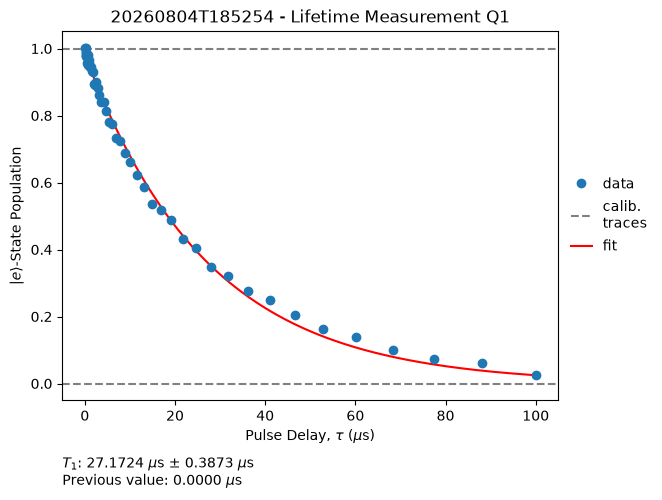

In [25]:
options = lifetime_measurement.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(False) # Plot figures


qubits_to_measure = [qubits[0]]

if log_spacing:
    delays = [log_sweep_help(delay_min, delay_max, n_delay)]
else:
    delays = [np.linspace(delay_min, delay_max, n_delay)]

exp_workflow = lifetime_measurement.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    delays=delays,
    options=options,
    temporary_parameters=temporary_parameters 
)

workflow_result = exp_workflow.run()

#### Update Parameters

In [26]:
if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    save(qpu, qpu_file_path)
    print('Updated global experiment parameters!\n')

analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)
ramsey.update_qpu(qpu, qubit_parameters["new_parameter_values"])
if transition == 'ge':
    print("ge_T1: ", qubit_to_measure.parameters.ge_T1)
elif transition == 'ef':
    print("ef_T1: ", qubit_to_measure.parameters.ef_T1)

Updated global experiment parameters!

{'new_parameter_values': {'Q1': {'ge_T1': 2.717241499235705e-05+/-3.872954285811073e-07}},
 'old_parameter_values': {'Q1': {'ge_T1': 0}}}
ge_T1:  2.717241499235705e-05


## DRAG Calibration

#### Experiment Parameters

In [30]:
update_global_parameters = True

transition = set_transition('ge')

n_avg_exponent = 13

q_min = -0.05
q_max = 0.05
n_q = 31

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.08.04 19:00:46.195] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.04 19:00:46.196] INFO      Workflow 'drag_q_scaling': execution started at 2026-08-04 16:00:46.195419Z   
[2026.08.04 19:00:46.196] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.04 19:00:46.374] INFO    Task 'temporary_qpu': started at 2026-08-04 16:00:46.374402Z
[2026.08.04 19:00:46.422] INFO    Task 'temporary_qpu': ended at 2026-08-04 16:00:46.420242Z
[2026.08.04 19:00:46.501] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-08-04 
[2026.08.04 19:00:46.510] INFO    16:00:46.501000Z
[2026.08.04 19:00:46.534] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-08-04 16:00:46.534171Z
[2026.08.04 19:00:46.614] INFO    Task 'create_experiment': started at 2026-08-04 16:00:46.614284Z
[2026.08.04 19:00:46.710] INFO    Task 'create_experiment': ended at 2026-08-04 16:00:46.710666Z
[202

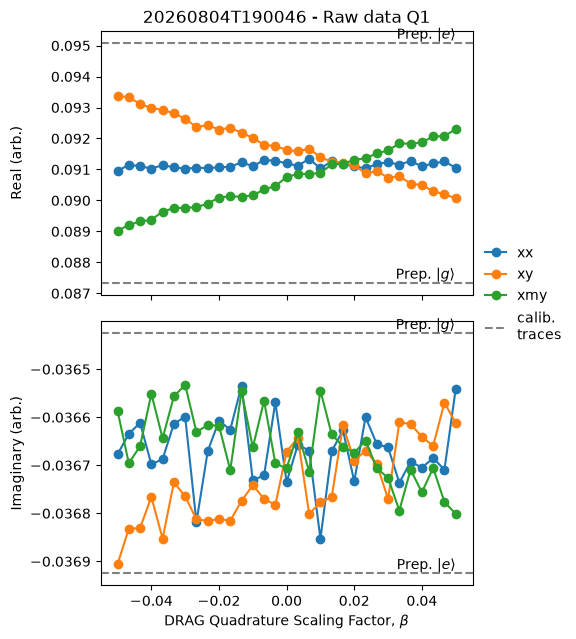

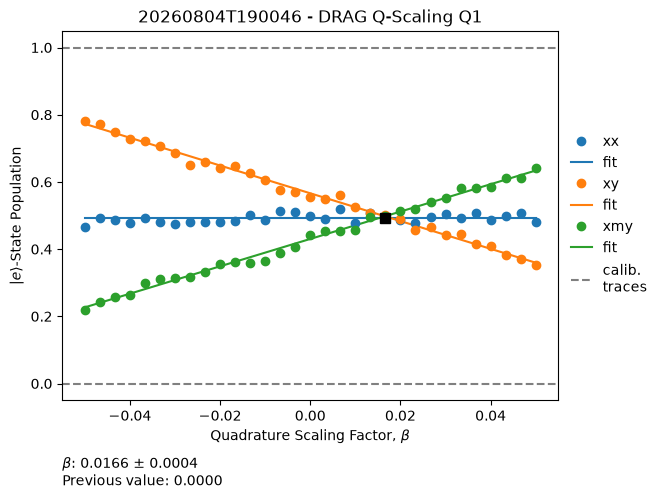

In [31]:
options = drag_q_scaling.experiment_workflow.options()
# options.update(True)  # updates the qubit parameter 'ge_drive_pulse["beta"]'
options.count(2**n_avg_exponent)
options.close_figures(False) # Plot figures

options.transition(transition)
options.cal_states(transition)

qubits_to_measure = [qubits[0]]

exp_workflow = drag_q_scaling.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    q_scalings=[np.linspace(q_min, q_max, n_q) for _ in qubits_to_measure],
    options=options,
)
workflow_result = exp_workflow.run()

#### Update Parameters

In [32]:
if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    print('Updated global experiment parameters!\n')

analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)
ramsey.update_qpu(qpu, qubit_parameters["new_parameter_values"])
if transition == 'ge':
    print("ge_drive_pulse[beta]: ", qubit_to_measure.parameters.ge_drive_pulse["beta"])
elif transition == 'ef':
    print("ef_drive_pulse[beta]: ", qubit_to_measure.parameters.ef_drive_pulse["beta"])

Updated global experiment parameters!

{'new_parameter_values': {'Q1': {'ge_drive_pulse.beta': 0.016556331217735108+/-0.00036290428142638615}},
 'old_parameter_values': {'Q1': {'ge_drive_pulse.beta': 0}}}
ge_drive_pulse[beta]:  0.016556331217735108


## Hahn-Echo

#### Experiment Parameters

In [33]:
update_global_parameters = True

transition = set_transition('ge')

n_avg_exponent = 13

delay_min = 0
delay_max = 100e-6
n_delay = 51
log_spacing = True

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.08.04 19:08:16.479] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.04 19:08:16.479] INFO      Workflow 'echo': execution started at 2026-08-04 16:08:16.479192Z             
[2026.08.04 19:08:16.481] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.04 19:08:16.767] INFO    Task 'temporary_qpu': started at 2026-08-04 16:08:16.767423Z
[2026.08.04 19:08:16.823] INFO    Task 'temporary_qpu': ended at 2026-08-04 16:08:16.823526Z
[2026.08.04 19:08:16.948] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-08-04 
[2026.08.04 19:08:16.948] INFO    16:08:16.943034Z
[2026.08.04 19:08:17.012] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-08-04 16:08:17.012184Z
[2026.08.04 19:08:17.123] INFO    Task 'create_experiment': started at 2026-08-04 16:08:17.123831Z
[2026.08.04 19:08:17.281] INFO    Task 'create_experiment': ended at 2026-08-04 16:08:17.281921Z
[202

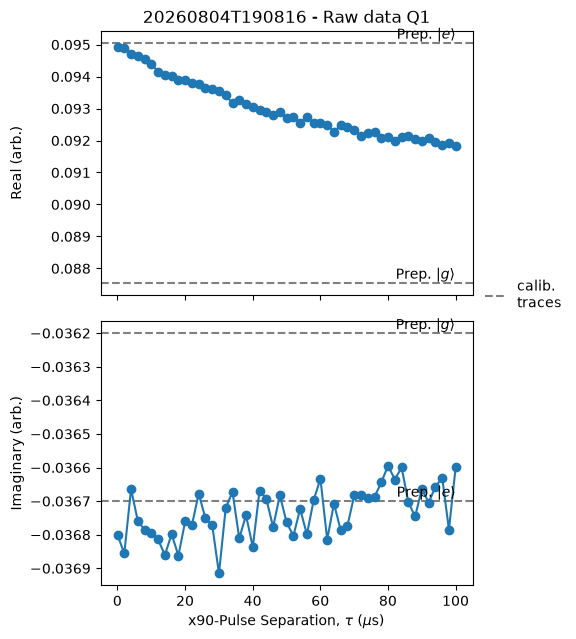

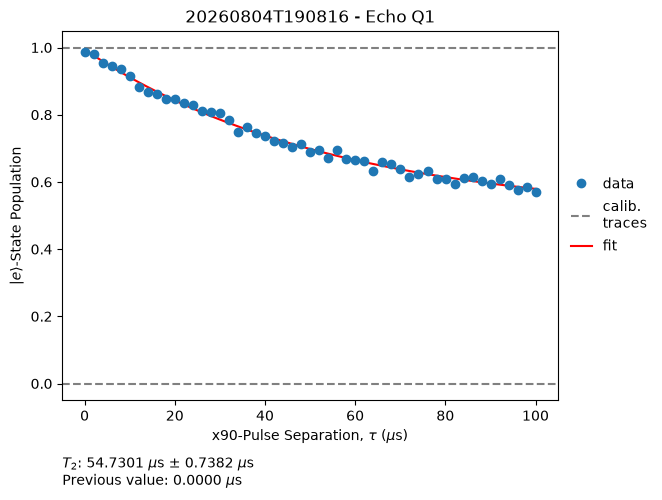

In [34]:
options = echo.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(False)

options.transition(transition)
options.cal_states(transition)

# Note: if neighbouring qubits are physically coupled by a resonator,
# you usually don't want to run Echo in parallel on them because
# your result will be skewed by strong residual-ZZ coupling.
# Next-nearest neighbours is typically okay.
qubits_to_measure = [qubits[0]]

delays = [
    np.linspace(delay_min, delay_max, n_delay)
]

exp_workflow = echo.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    delays=delays,
    options=options,
    temporary_parameters=temporary_parameters
)

workflow_result = exp_workflow.run()

#### Update Parameters

In [35]:
if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    save(qpu, qpu_file_path)
    print('Updated global experiment parameters!\n')

analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)
ramsey.update_qpu(qpu, qubit_parameters["new_parameter_values"])
if transition == 'ge':
    print("ge_T2: ", qubit_to_measure.parameters.ge_T2)
elif transition == 'ef':
    print("ef_T2: ", qubit_to_measure.parameters.ef_T2)

Updated global experiment parameters!

{'new_parameter_values': {'Q1': {'ge_T2': 5.4730084836242706e-05+/-7.382357702315173e-07}},
 'old_parameter_values': {'Q1': {'ge_T2': 0}}}
ge_T2:  5.4730084836242706e-05
